## Setup/Load Data

In [2]:
pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.8/38.1 MB 1.5 MB/s eta 0:00:25
   - -------------------------------------- 1.0/38.1 MB 1.6 MB/s eta 0:00:24
   - -------------------------------------- 1.6/38.1 MB 1.6 MB/s eta 0:00:24
   - -------------------------------------- 1.8/38.1 MB 1.6 MB/s eta 0:00:23
   -- ------------------------------------- 2.1/38.1 MB 1.5 MB/s eta 0:00:24
   -- ------------------------------------- 2.4/38.1 MB 1.6 MB/s eta 0:00:23
   --- ------------------------------------ 2.9/38.1 MB 1.6 MB/s eta 0:00:23
   --- ------------------------------------ 3.1/38.1 MB 1.6 MB/s eta 0:00:22
   --- ------------------------------------ 3.7/38.1 MB 1.6 MB/s eta 0:00:22
   ---- ----------------------------------- 3.9/38.1 MB 1.6 MB/s eta 0:00:21
   ---- -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

import shap
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset UCI
df = pd.read_csv('bank-additional-full.csv', sep = ';')

print(df.shape)
print(df.head())
print(df['y'].value_counts())  # Target variable distribution


d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m 

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


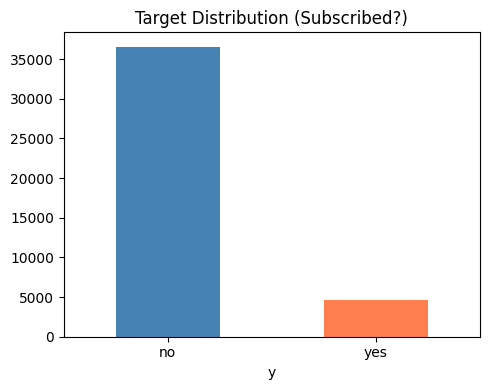

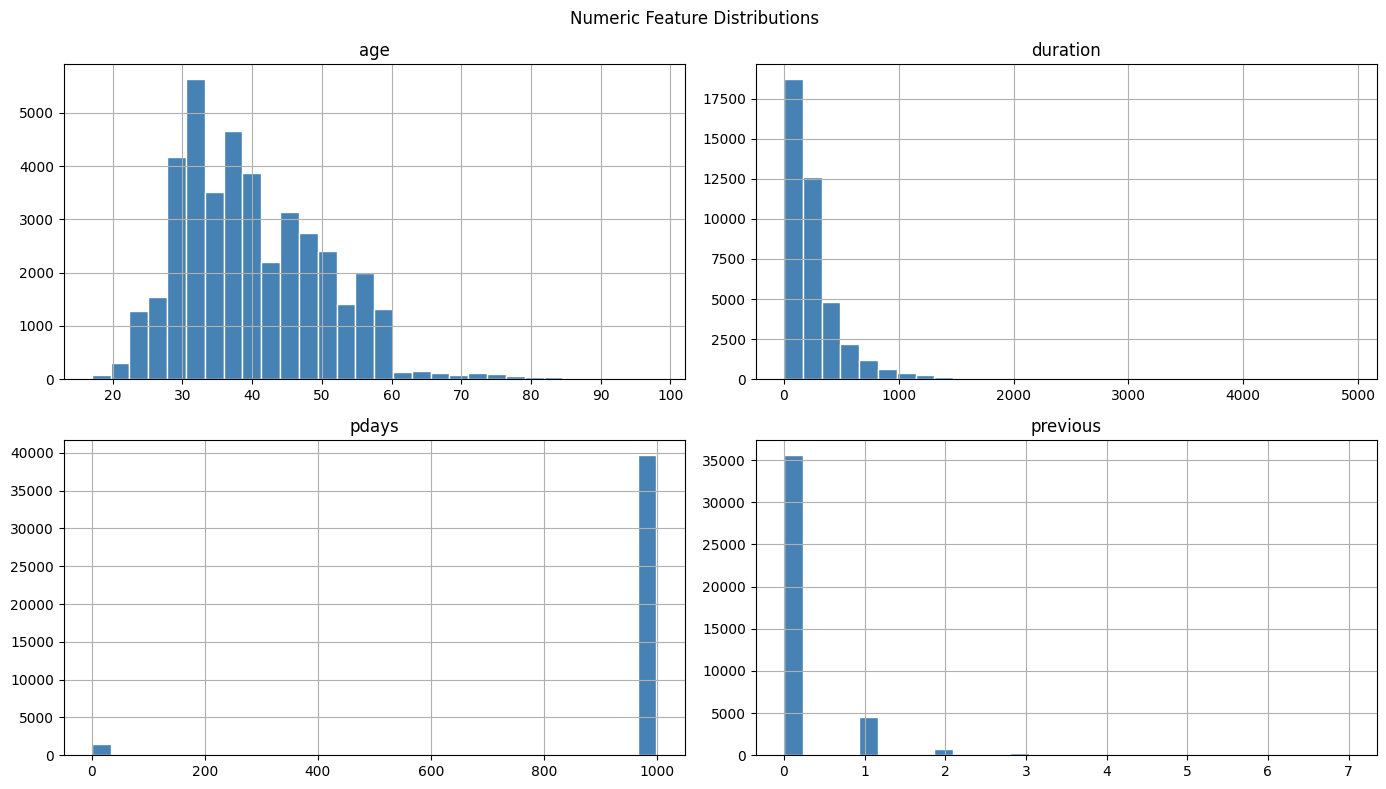

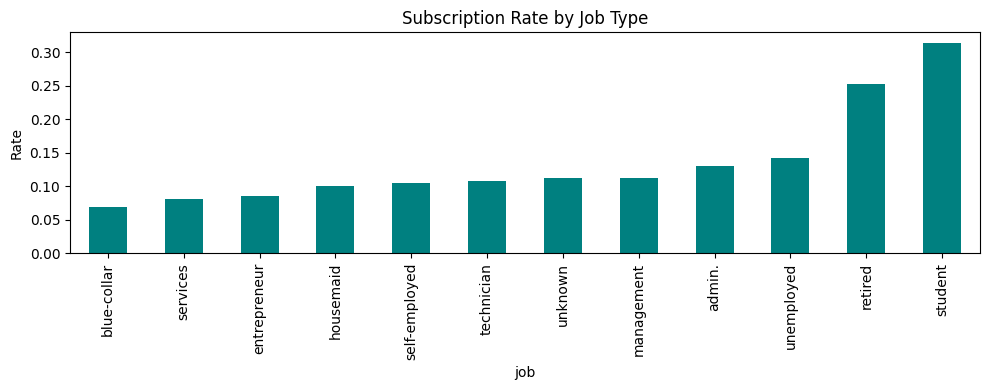

In [5]:
# Check Nulls
print(df.isnull().sum())

#Target Distribution
plt.figure(figsize=(5,4))
df['y'].value_counts().plot(kind = 'bar', color=['steelblue', 'coral'])
plt.title('Target Distribution (Subscribed?)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('target_dist.png', dpi = 150)
plt.show()

# Numeric Feature Distribution
num_cols = ['age', 'duration', 'pdays', 'previous']
df[num_cols].hist(bins=30, figsize = (14,8), color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.savefig('numeric_dist.png', dpi = 150)
plt.show()

# Subscription by job type
plt.figure(figsize=(10,4))
job_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values()
job_rate.plot(kind = 'bar', color='teal')
plt.title('Subscription Rate by Job Type')
plt.ylabel('Rate')
plt.tight_layout()
plt.savefig('job_rate.png', dpi =150)
plt.show()


In [8]:
# Drop Duration (leaking feature)
df = df.drop(columns=['duration'], errors = 'ignore')

# Handle Unknowns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

for col in cat_cols:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# Encode Target
df['y'] = (df['y'] == 'yes').astype(int)
print(df['y'].value_counts())

#Encode Categorical 
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)
print(df.shape)    

y
0    36548
1     4640
Name: count, dtype: int64
age                 int64
job                 int64
marital             int64
education           int64
default             int64
housing             int64
loan                int64
contact             int64
month               int64
day_of_week         int64
campaign            int64
pdays               int64
previous            int64
poutcome            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int64
dtype: object
(41188, 20)


In [9]:
# Train Test Split
x = df.drop(columns=['y'])
y = df['y']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {x_train.shape}, Test size: {x_test.shape}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate: {y_test.mean():.2%}")

Train size: (32950, 19), Test size: (8238, 19)
Train positive rate: 11.27%
Test positive rate: 11.26%


In [11]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print("Models trained successfully")

# Accuracy %
print(f"LR Train Accuracy: {lr.score(x_train, y_train):.2%}")
print(f"RF Train Accuracy: {rf.score(x_train, y_train):.2%}")

Models trained successfully
LR Train Accuracy: 77.42%
RF Train Accuracy: 99.40%


## Classification Report 

In [14]:
print("=" * 20)
print("LOGISTIC REGRESSION")
print("=" * 20)
print(classification_report(y_test, lr_pred, target_names=['No', 'Yes']))

print("=" * 14)
print("RANDOM FOREST")
print("=" * 14)
print(classification_report(y_test, rf_pred, target_names = ['No', 'Yes']))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.95      0.79      0.86      7310
         Yes       0.30      0.70      0.41       928

    accuracy                           0.78      8238
   macro avg       0.62      0.74      0.64      8238
weighted avg       0.88      0.78      0.81      8238

RANDOM FOREST
              precision    recall  f1-score   support

          No       0.91      0.97      0.94      7310
         Yes       0.56      0.28      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238



## Confusion Matrix

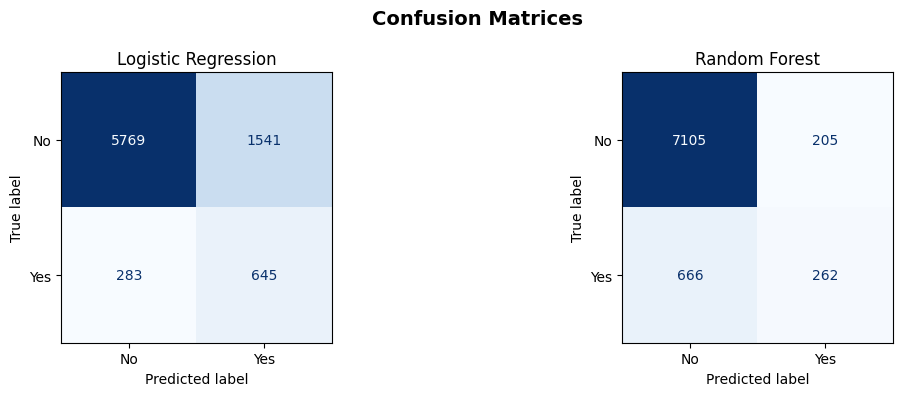

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

for ax, pred, title in zip(axes, [lr_pred, rf_pred], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices', fontsize = 14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi = 150)
plt.show()    

## ROC Curve

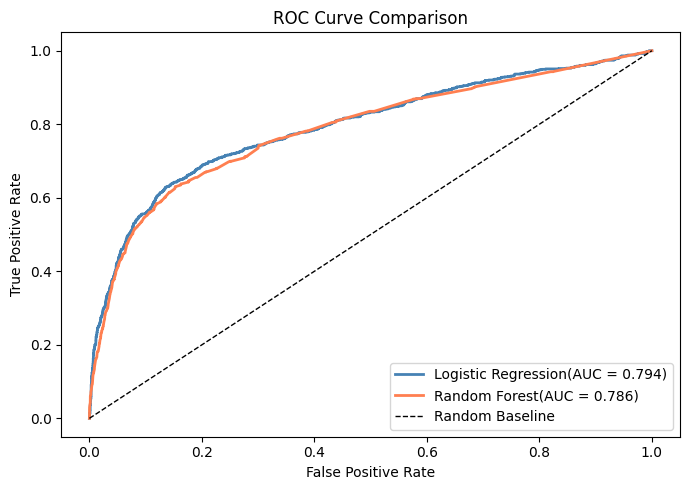

In [16]:
plt.figure(figsize=(7,5))

for model, name, color in zip( [lr, rf], ['Logistic Regression', 'Random Forest'],['steelblue', 'coral']):
    y_prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color = color, lw=2, label =f'{name}(AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## SHAP Explainability

## 1) Initialize SHAP Explainer

In [18]:
# TreeExplainer is optimized specifically for Random Forest
explainer = shap.TreeExplainer(rf)

# Use sample test data, full set is slow
x_test_sample = x_test.sample(200, random_state=42)
shap_values = explainer.shap_values(x_test_sample)

print("SHAP values shape:", shap_values.shape)
print("Done")

SHAP values shape: (200, 19, 2)
Done


## 2) Global Feature Importance

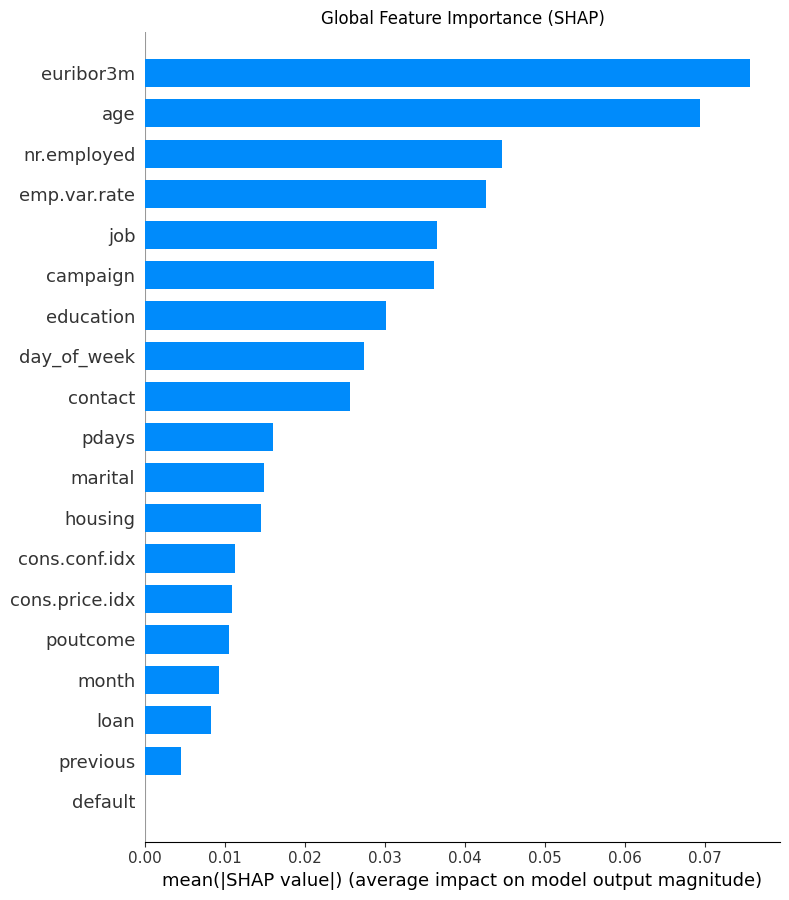

In [19]:
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    x_test_sample,
    plot_type='bar',
    show = False
)

plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 3) Beeswarm Plot

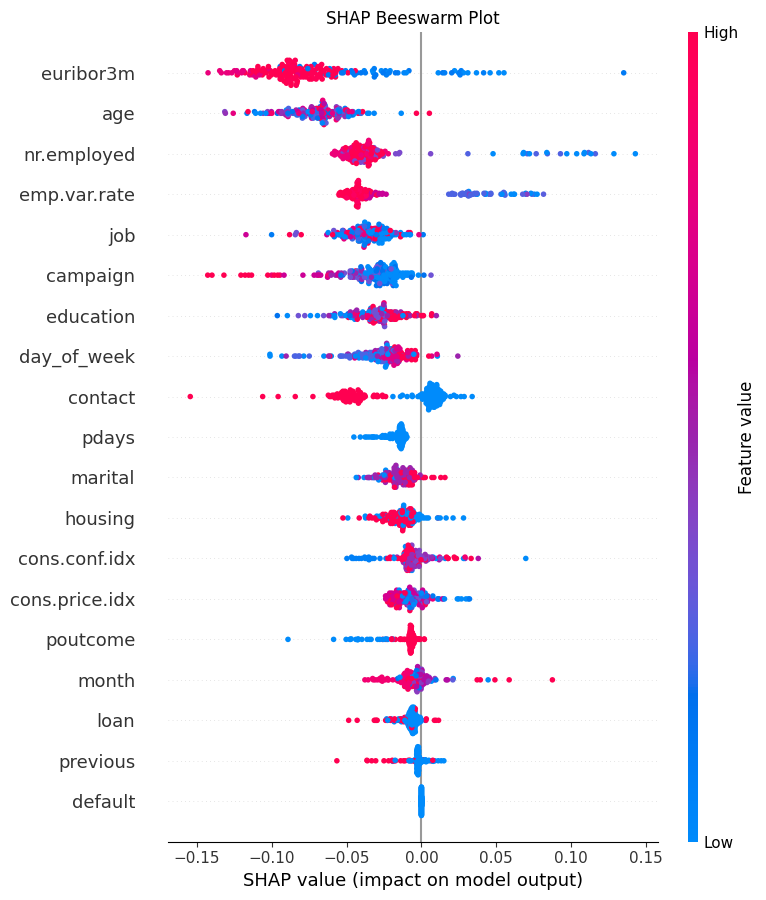

In [20]:
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    x_test_sample,
    show=False
)

plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig('shap_beesawrm.png', dpi=150, bbox_inches= 'tight')
plt.show()

## 4) Five Individual Predictions (Waterfall Plots) 


--- Prediction1 | Actual: No | Predicted: No | Confidence:  3.00%--


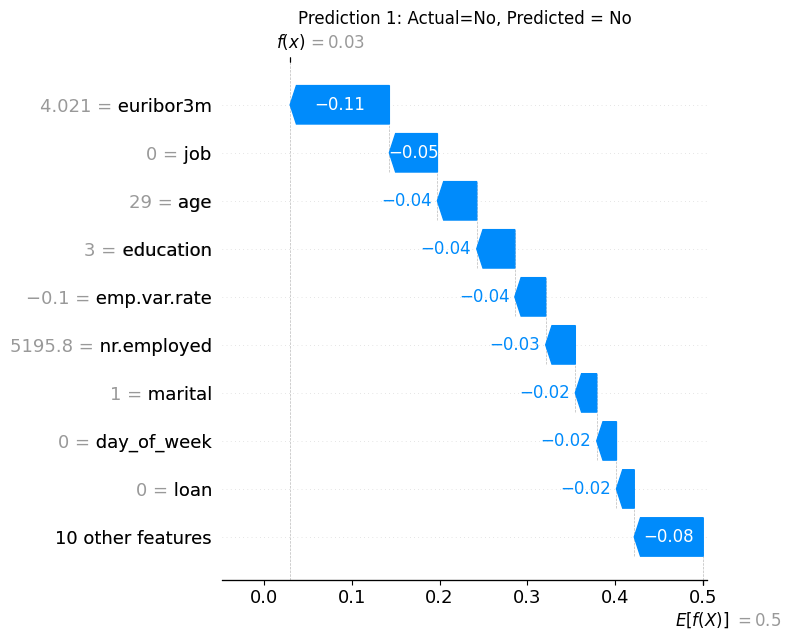


--- Prediction2 | Actual: No | Predicted: No | Confidence:  3.00%--


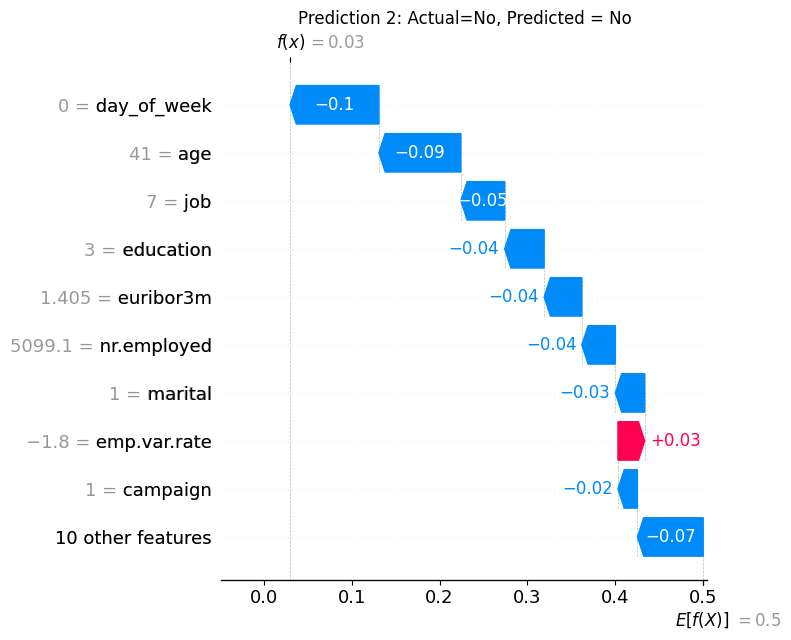


--- Prediction3 | Actual: No | Predicted: No | Confidence:  11.89%--


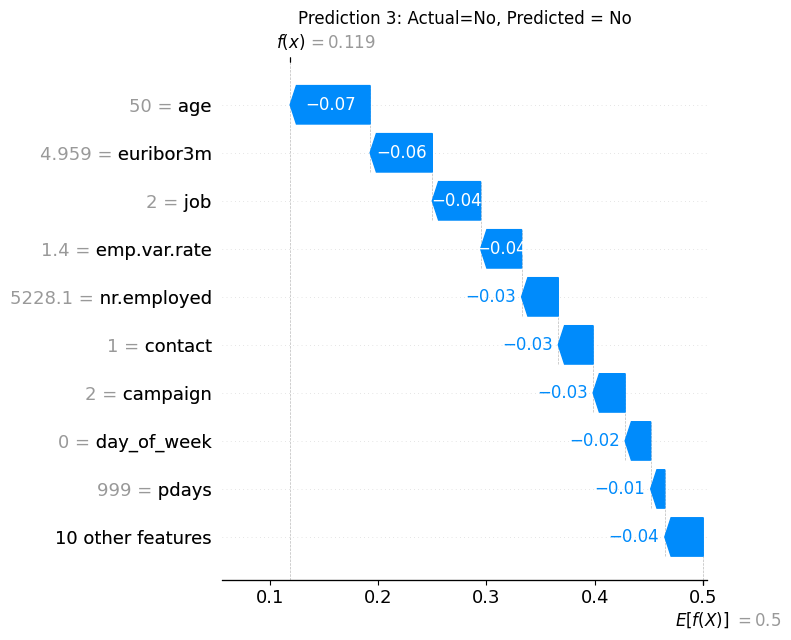


--- Prediction4 | Actual: No | Predicted: No | Confidence:  0.00%--


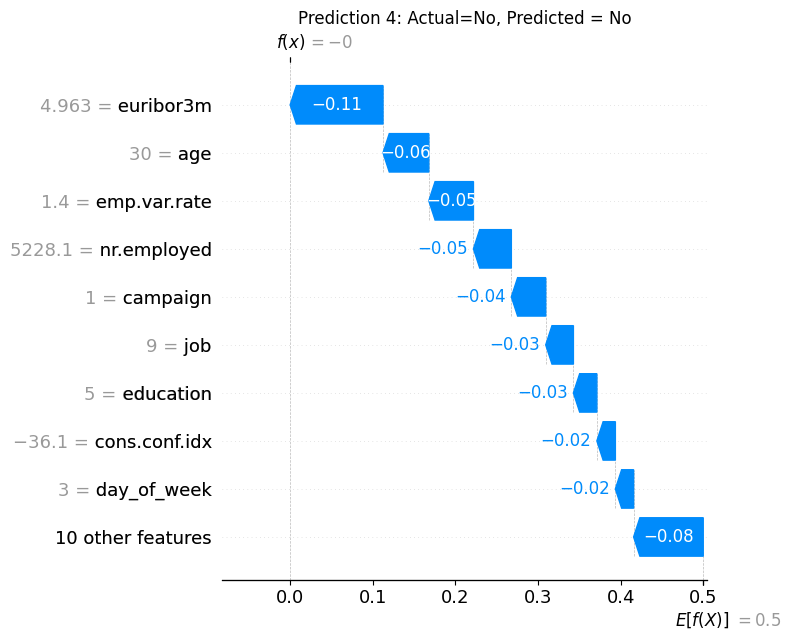


--- Prediction5 | Actual: No | Predicted: No | Confidence:  0.00%--


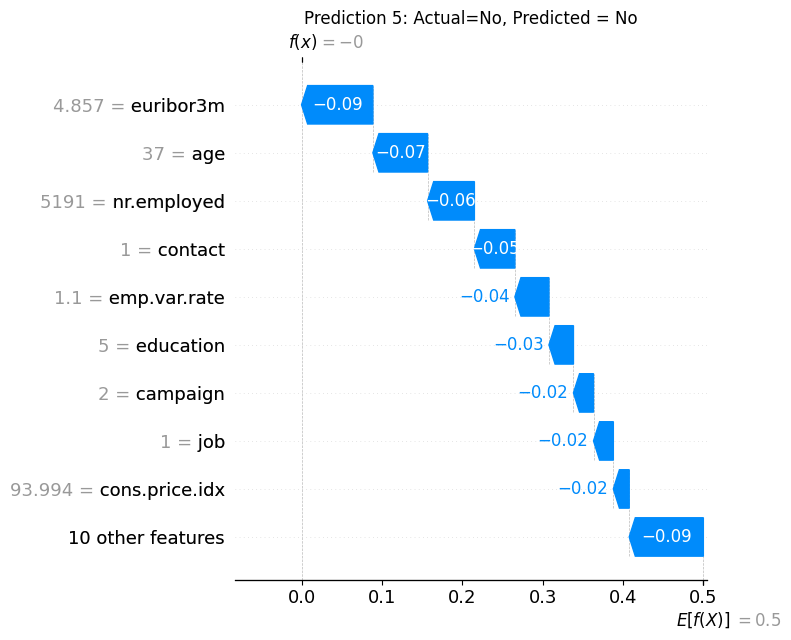

In [25]:
# Task requires explaining at least 5 individual predictions
# Pick 5 interesting ones, mix of correct & incorrect predictions

rf_probs = rf.predict_proba(x_test_sample)[:,1]
sample_indices = [0, 1, 2, 3, 4]

for i in sample_indices:
    actual = y_test.iloc[i]
    predicted = rf_pred[x_test.index.get_loc(x_test_sample.index[i])]
    prob = rf_probs[i]

    print(f"\n--- Prediction{i+1} | Actual: {'Yes' if actual == 1 else 'No'} | " f"Predicted: {'Yes' if predicted==1 else 'No'} | Confidence: {prob: .2%}--")

    shap.plots.waterfall(
        shap.Explanation(
            values = shap_values[i, :, 1],
            base_values = explainer.expected_value[1],
            data=x_test_sample.iloc[i],
            feature_names=x_test_sample.columns.tolist()
        ),
        show=False
    )
    plt.title(f'Prediction {i+1}: Actual={"Yes" if actual==1 else"No"}, 'f'Predicted = {"Yes" if predicted==1 else"No"}' )
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Conclusion

- Trained Logistic Regression and Random Forest on the Bank Marketing dataset
- Random Forest outperformed LR with higher AUC and F1 on the minority class
- Key predictors: nr.employed, euribor3m, poutcome, contact, month
- 'duration' was excluded to avoid data leakage (only known post-call)
- SHAP analysis revealed economic indicators (euribor3m, nr.employed) have the strongest global influence on subscription likelihood
- Individual SHAP waterfall plots explain each prediction transparently, making the model interpretable for business stakeholders